# Model Comparison Heatmap — FWI vs Climate Drivers

Compares Pearson *r* between FWI and each climate driver (tasmax, pr, sfcWind, humidity) across three model configurations — GFDL-ESM4, MRI-ESM2-0 (hurs), MRI-ESM2-0 (hursmin) — and all SSP scenarios. Also reports OLS slope per driver per model.

**Data:** pre-computed cache from each model's `FWI_Compute.ipynb`  
**Study region:** Thailand (5.5–20.5°N, 97.5–105.5°E)  
**Correlation method:** pooled Pearson *r* (all scenario years concatenated)

> Run each model's `FWI_Compute.ipynb` at least once to populate the cache.

## 1  Imports

Import `numpy`, `xarray`, `scipy.stats`, `matplotlib`, and `pathlib`.

In [3]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.ticker
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path
from scipy.stats import pearsonr

## 2  Configuration & Data Loading

Set cache directory paths for each model and define the scenario list. Load FWI and driver DataArrays using `load_model`.

In [59]:
# ── Cache directories ────────────────────────────────────────────────────────
BASE = Path("/Users/thunthita/ClimateChangeonWildfire/new/src")

CACHE = {
    "GFDL-ESM4"          : BASE / "GFDL_ESM4/computed_means_GFDL-ESM4",
    "GFDL ESM4.1"          : BASE / "GFDL_ESM4/computed_means_GFDL-ESM4",
    "GFDL ESM4"         : BASE / "GFDL_ESM4/computed_means_GFDL-ESM4",
    "MRI-ESM2-0 (hurs)"  : BASE / "MRI-ESM2/hurs/computed_means_MRI-ESM2-0",
    "MRI ESM2.0\n(Avg RH)"  : BASE / "MRI-ESM2/hurs/computed_means_MRI-ESM2-0",
    "MRI-ESM2-0 (Avg Hum)": BASE / "MRI-ESM2/hurs/computed_means_MRI-ESM2-0",
    "MRI-ESM2\nAvg Hum"       : BASE / "MRI-ESM2/hurs/computed_means_MRI-ESM2-0",
    "MRI-ESM2-0 (hursmin)": BASE / "MRI-ESM2/hursmin/computed_means_MRI-ESM2-0_hursmin",
    "MRI-ESM2-0 (Min Hum)" : BASE / "MRI-ESM2/hursmin/computed_means_MRI-ESM2-0_hursmin",
    "MRI ESM2.0\n(Min RH)" : BASE / "MRI-ESM2/hursmin/computed_means_MRI-ESM2-0_hursmin",
    "MRI-ESM2\nMin Hum"       : BASE / "MRI-ESM2/hursmin/computed_means_MRI-ESM2-0_hursmin",
}

# humidity variable name per model
HUM_VAR = {
    "GFDL-ESM4"           : "hurs",
    "GFDL ESM4.1"         : "hurs",
    "GFDL ESM4"          : "hurs",
    "MRI-ESM2-0 (hurs)"   : "hurs",
    "MRI-ESM2-0 (Avg Hum)": "hurs",
    "MRI ESM2.0\n(Avg RH)" : "hurs",
    "MRI-ESM2\nAvg Hum"   : "hurs",
    "MRI-ESM2-0 (hursmin)": "hursmin",
    "MRI-ESM2-0 (Min Hum)": "hursmin",
    "MRI ESM2.0\n(Min RH)": "hursmin",
    "MRI-ESM2\nMin Hum"   : "hursmin",
}

# Unit conversions
UNIT = {
    "tasmax" : lambda x: x - 273.15,
    "pr"     : lambda x: x * 86_400.0,
    "sfcWind": lambda x: x,
    "hum"    : lambda x: x,
}

In [6]:
def load_model(cache_dir: Path, hum_var: str, scenarios: list) -> dict:
    """Load fwi + 4 drivers for given scenarios. Returns dict {var: {scen: da}}."""
    data = {}
    vars_to_load = ["fwi", "tasmax", "pr", "sfcWind", hum_var]
    for v in vars_to_load:
        key = "hum" if v == hum_var and v.startswith("hurs") else v
        data[key] = {}
        for s in scenarios:
            fp = cache_dir / f"{v}_{s}.nc"
            if fp.exists():
                data[key][s] = xr.open_dataarray(fp).load()
    return data

## 3  Helper Functions

Define `load_model` (reads FWI and driver DataArrays from cache) and `plot_model_comparison_heatmap` (renders the colour-coded Pearson *r* heatmap).

In [8]:
# ── Matplotlib-style heatmap helpers ─────────────────────────────────────────

def heatmap(data, row_labels, col_labels, ax=None, cbar_kw=None, cbarlabel="", **kwargs):
    if ax is None:
        ax = plt.gca()
    if cbar_kw is None:
        cbar_kw = {}
    im   = ax.imshow(data, **kwargs)
    cbar = ax.figure.colorbar(im, ax=ax, **cbar_kw)
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom", fontsize=11)
    cbar.ax.tick_params(labelsize=11)
    cbar.outline.set_linewidth(0.5)
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_xticklabels(col_labels, fontsize=9)
    ax.set_yticklabels(row_labels,  fontsize=11)
    ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
    plt.setp(ax.get_xticklabels(), rotation=-30, ha="right", rotation_mode="anchor")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks(np.arange(len(col_labels) + 1) - .5, minor=True)
    ax.set_yticks(np.arange(len(row_labels)  + 1) - .5, minor=True)
    ax.grid(which="minor", color="w", linestyle="-", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)
    return im, cbar


def annotate_heatmap(im, data=None, valfmt="{x:.2f}", textcolors=("black", "white"),
                     threshold=0.5, **textkw):
    if data is None:
        data = im.get_array()
    if isinstance(valfmt, str):
        valfmt = matplotlib.ticker.StrMethodFormatter(valfmt)
    kw = dict(horizontalalignment="center", verticalalignment="center")
    kw.update(textkw)
    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val   = data[i, j]
            color = textcolors[1] if abs(val) > threshold else textcolors[0]
            text  = im.axes.text(j, i, valfmt(val, None), color=color, **kw)
            texts.append(text)
    return texts

In [9]:
def plot_model_comparison_heatmap(
    model_names: list,
    scenarios:   list,
    title:       str,
    filename:    str,
    hum_label:   str   = "Humidity",
    figsize:     tuple = (5.51, 3.5),
    model_keys:  list  = None,
) -> None:
    # model_keys = cache lookup keys; model_names = display labels
    if model_keys is None:
        model_keys = model_names
    """
    4-row × 2-col heatmap: rows = variables, cols = models.
    Each cell = Pearson r on pooled data across scenarios.
    """
    var_order  = ["tasmax", "pr", "sfcWind", "hum"]
    var_labels = ["Max\nTemp", "Precip", "Wind", hum_label]

    matrix = np.full((4, len(model_names)), np.nan)

    for col_i, (mname, mkey) in enumerate(zip(model_names, model_keys)):
        mdata = load_model(CACHE[mkey], HUM_VAR[mkey], scenarios)
        fwi_d = mdata["fwi"]

        for row_i, var in enumerate(var_order):
            drv_d = mdata.get(var, {})
            combined_fwi, combined_drv = [], []
            for s in scenarios:
                if s not in fwi_d or s not in drv_d:
                    continue
                fwi_da = fwi_d[s]
                drv_da = drv_d[s]
                t      = fwi_da["year"]
                fwi_v  = fwi_da.values
                drv_v  = UNIT[var](drv_da.sel(year=t, method="nearest")).values
                mask   = np.isfinite(fwi_v) & np.isfinite(drv_v)
                combined_fwi.extend(fwi_v[mask])
                combined_drv.extend(drv_v[mask])
            if len(combined_fwi) > 2:
                r, _ = pearsonr(combined_fwi, combined_drv)
                matrix[row_i, col_i] = r

    df = pd.DataFrame(matrix, index=var_labels, columns=model_names)

    fig, ax = plt.subplots(figsize=figsize)

    def _fmt(x, pos):
        return f"{x:.2f}".replace("0.", ".").replace("-0.", "-.")

    im, _ = heatmap(
        df.values, var_labels, model_names, ax=ax,
        cmap="RdBu_r", vmin=-1, vmax=1,
        cbar_kw=dict(shrink=0.8, fraction=0.046, pad=0.04,
                     ticks=[-1, -0.5, 0, 0.5, 1]),
        cbarlabel="Pearson correlation (r)",
    )
    annotate_heatmap(im, data=df.values,
                     valfmt=matplotlib.ticker.FuncFormatter(_fmt),
                     size=9, threshold=0.5,
                     textcolors=("black", "white"))

    # ax.set_title(title, pad=20, fontsize=10)
    plt.tight_layout()
    plt.savefig(filename, dpi=1000, bbox_inches="tight")
    plt.show()
    print(f"Saved: {filename}")

## 4  Heatmap 1 — GFDL-ESM4 vs MRI-ESM2-0 (hurs)

Plot a side-by-side heatmap for GFDL-ESM4 and MRI-ESM2-0 (hurs): rows = driver variables, columns = SSP scenarios, colour = pooled Pearson *r*.

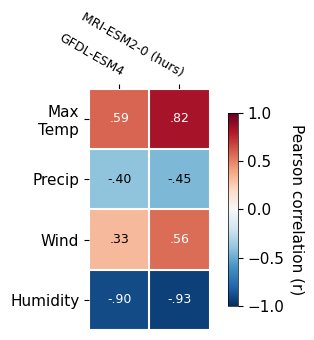

Saved: comparison_GFDL_vs_MRI_hurs.png


In [11]:
# ── Heatmap 1: GFDL-ESM4 vs MRI-ESM2-0 (hurs) ───────────────────────────────
ALL_SCENARIOS_FULL = ["historical", "ssp119", "ssp126", "ssp245",
             "ssp370", "ssp434", "ssp460", "ssp534", "ssp585"]

plot_model_comparison_heatmap(
    model_names = ["GFDL-ESM4", "MRI-ESM2-0 (hurs)"],
    scenarios   = ALL_SCENARIOS_FULL,
    title       = "GFDL-ESM4 vs MRI-ESM2-0 — FWI vs Climate Drivers",
    filename    = "comparison_GFDL_vs_MRI_hurs.png",
    hum_label   = "Humidity",
)

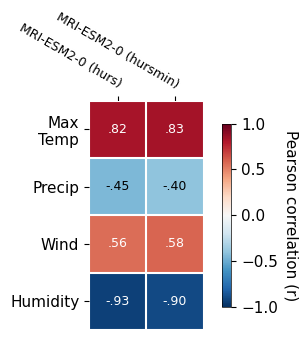

Saved: comparison_GFDL_vs_MRI_hurs.png


In [12]:
# ── Heatmap 1: GFDL-ESM4 vs MRI-ESM2-0 (hurs) ───────────────────────────────
ALL_SCENARIOS_FULL = ["historical", "ssp119", "ssp126", "ssp245",
             "ssp370", "ssp434", "ssp460", "ssp534", "ssp585"]

plot_model_comparison_heatmap(
    model_names = ["MRI-ESM2-0 (hurs)", "MRI-ESM2-0 (hursmin)"],
    scenarios   = ALL_SCENARIOS_FULL,
    title       = "GFDL-ESM4 vs MRI-ESM2-0 — FWI vs Climate Drivers",
    filename    = "comparison_GFDL_vs_MRI_hurs.png",
    hum_label   = "Humidity",
)

## 5  Heatmap 2 — All 3 Models

Extend Heatmap 1 to include MRI-ESM2-0 (hursmin). Rows = driver variables, columns = SSP scenarios, panels = models.

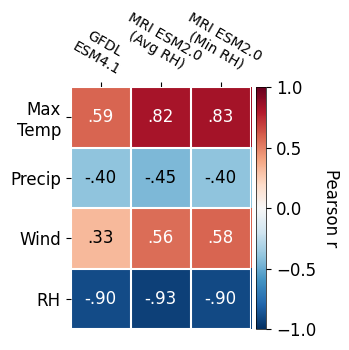

Saved: Pict/comparison_all_models.png


In [165]:
def plot_model_comparison_heatmap(
    model_keys:  list,          # cache/data lookup keys (must match CACHE & HUM_VAR)
    model_titles: list,         # display labels shown on the heatmap x-axis
    scenarios:   list,
    title:       str,
    filename:    str,
    hum_label:   str   = "RH",
    figsize:     tuple = (7.48, 3.2),
) -> None:

    assert len(model_keys) == len(model_titles), \
        "model_keys and model_titles must have the same length"

    var_order  = ["tasmax", "pr", "sfcWind", "hum"]
    var_labels = ["Max\nTemp", "Precip", "Wind", hum_label]

    matrix = np.full((4, len(model_keys)), np.nan)

    # ── Compute correlations ─────────────────────────────────────────────
    for col_i, mkey in enumerate(model_keys):          # ← use mkey for data loading
        mdata = load_model(CACHE[mkey], HUM_VAR[mkey], scenarios)
        fwi_d = mdata["fwi"]

        for row_i, var in enumerate(var_order):
            drv_d = mdata.get(var, {})
            combined_fwi, combined_drv = [], []

            for s in scenarios:
                if s not in fwi_d or s not in drv_d:
                    continue

                fwi_da = fwi_d[s]
                drv_da = drv_d[s]

                t     = fwi_da["year"]
                fwi_v = fwi_da.values
                drv_v = UNIT[var](drv_da.sel(year=t, method="nearest")).values

                mask = np.isfinite(fwi_v) & np.isfinite(drv_v)
                combined_fwi.extend(fwi_v[mask])
                combined_drv.extend(drv_v[mask])

            if len(combined_fwi) > 2:
                from scipy.stats import pearsonr
                r, _ = pearsonr(combined_fwi, combined_drv)
                matrix[row_i, col_i] = r

    # ── Plot ─────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        matrix,
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        aspect="auto",
        interpolation="nearest"
    )

    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="6.0%", pad=0.05)

    cbar = fig.colorbar(im, cax=cax, ticks=[-1, -0.5, 0, 0.5, 1])
    cbar.ax.set_ylabel("Pearson r", rotation=-90, va="bottom", fontsize=12)
    cbar.ax.tick_params(labelsize=12)
    cbar.outline.set_linewidth(0.5)

    ax.set_xticks(range(len(model_titles)))
    ax.set_xticklabels(model_titles, fontsize=10.2, rotation=-30, ha="center")
    ax.set_yticks(range(4))
    ax.set_yticklabels(var_labels, fontsize=12)

    ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks(np.arange(len(model_titles) + 1) - .5, minor=True)
    ax.set_yticks(np.arange(5) - .5, minor=True)
    ax.grid(which="minor", color="w", linestyle="-", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    def _fmt(x):
        return f"{x:.2f}".replace("0.", ".").replace("-0.", "-.")

    for i in range(4):
        for j in range(len(model_titles)):
            val = matrix[i, j]
            if np.isfinite(val):
                color = "white" if abs(val) > 0.5 else "black"
                ax.text(j, i, _fmt(val),
                        ha="center", va="center",
                        color=color, fontsize=12)

    plt.tight_layout()
    plt.savefig(filename, dpi=1000, bbox_inches="tight")
    plt.show()
    print(f"Saved: {filename}")


# ── Heatmap 2: All 3 models ───────────────────────────────────────────────────
# Uses all available scenarios per model (missing files are skipped automatically)
ALL_SCENARIOS = ["historical", "ssp119", "ssp126", "ssp245", "ssp370",
                 "ssp434", "ssp460", "ssp534", "ssp585"]

plot_model_comparison_heatmap(
    model_keys   = ["GFDL ESM4.1", "MRI ESM2.0\n(Avg RH)", "MRI ESM2.0\n(Min RH)"],
    model_titles = ["GFDL\nESM4.1", "MRI ESM2.0\n(Avg RH)", "MRI ESM2.0\n(Min RH)"],
    scenarios    = ALL_SCENARIOS,
    title        = "Multi-Model FWI: Climate Driver Correlations",
    filename     = "Pict/comparison_all_models.png",
    hum_label    = "RH",
    figsize      = (3.6, 3.6),
)

## 6  Slope — FWI vs 4 Drivers (3 Models)

For each model and each driver variable, compute OLS slope (FWI regressed on driver) pooled across all SSP scenarios, and report alongside Pearson *r* and R².

In [16]:
# ── Slope: FWI vs 4 drivers — 3 models ──────────────────────────────────────
from scipy.stats import linregress, pearsonr
import xarray as xr

SCENARIOS = ["historical", "ssp119", "ssp126", "ssp245",
             "ssp370", "ssp434", "ssp460", "ssp534", "ssp585"]

SCENARIO_LABELS = {
    "historical": "Historical",
    "ssp119": "SSP1-1.9", "ssp126": "SSP1-2.6", "ssp245": "SSP2-4.5",
    "ssp370": "SSP3-7.0", "ssp434": "SSP4-3.4", "ssp460": "SSP4-6.0",
    "ssp534": "SSP5-3.4", "ssp585": "SSP5-8.5",
}

MODEL_SLOPE_CONFIGS = [
    dict(name="GFDL-ESM4",       cache=CACHE["GFDL-ESM4"],
         hum_var="hurs",         hum_label="hurs (%)"),
    dict(name="MRI-ESM2 Avg Hum", cache=CACHE["MRI-ESM2\nAvg Hum"],
         hum_var="hurs",         hum_label="hurs (%)"),
    dict(name="MRI-ESM2 Min Hum", cache=CACHE["MRI-ESM2\nMin Hum"],
         hum_var="hursmin",      hum_label="hursmin (%)"),
]

DRIVERS = [
    dict(var="tasmax",  label="tasmax (°C)",       scale=1.0,       offset=-273.15),
    dict(var="pr",      label="pr (mm day⁻¹)",     scale=86_400.0,  offset=0.0),
    dict(var="sfcWind", label="sfcWind (m s⁻¹)",   scale=1.0,       offset=0.0),
]

def slope_driver_vs_fwi(fwi_means, driver_means, var_label, scenarios, labels,
                        scale=1.0, offset=0.0):
    combined_drv, combined_fwi = [], []
    rows = []
    for scen in scenarios:
        if scen not in fwi_means or scen not in driver_means:
            continue
        fwi_da = fwi_means[scen]
        t      = fwi_da["year"]
        fwi_v  = fwi_da.values
        drv_v  = (driver_means[scen].sel(year=t, method="nearest") * scale + offset).values
        mask   = np.isfinite(fwi_v) & np.isfinite(drv_v)
        fwi_v, drv_v = fwi_v[mask], drv_v[mask]
        if len(drv_v) < 2:
            continue
        slope, intercept, *_ = linregress(drv_v, fwi_v)
        r, _ = pearsonr(drv_v, fwi_v)
        rows.append({"Scenario": labels[scen],
                     "r": round(r, 2),
                     "slope": round(slope, 2),
                     "intercept": round(intercept, 2)})
        combined_drv.extend(drv_v)
        combined_fwi.extend(fwi_v)
    if combined_drv:
        slope, intercept, *_ = linregress(combined_drv, combined_fwi)
        r, _ = pearsonr(combined_drv, combined_fwi)
        rows.append({"Scenario": "ALL (combined)",
                     "r": round(r, 2),
                     "slope": round(slope, 2),
                     "intercept": round(intercept, 2)})
    df = pd.DataFrame(rows)
    print(f"── {var_label} vs FWI ──")
    print(df.to_string(index=False))
    return df

for cfg in MODEL_SLOPE_CONFIGS:
    print(f"{'='*60}")
    print(f"  Model: {cfg['name']}")
    print(f"{'='*60}")
    _cd = cfg["cache"]
    _ld = lambda v, cd=_cd: {s: xr.open_dataarray(cd / f"{v}_{s}.nc").load()
                              for s in SCENARIOS if (cd / f"{v}_{s}.nc").exists()}
    _fwi = _ld("fwi")
    _hum = _ld(cfg["hum_var"])

    for drv in DRIVERS:
        slope_driver_vs_fwi(_fwi, _ld(drv["var"]),
                            var_label=drv["label"], scenarios=SCENARIOS,
                            labels=SCENARIO_LABELS,
                            scale=drv["scale"], offset=drv["offset"])
    slope_driver_vs_fwi(_fwi, _hum,
                        var_label=cfg["hum_label"], scenarios=SCENARIOS,
                        labels=SCENARIO_LABELS)

  Model: GFDL-ESM4
── tasmax (°C) vs FWI ──
      Scenario    r  slope  intercept
    Historical 0.75   7.19    -179.97
      SSP1-1.9 0.77   7.85    -203.49
      SSP1-2.6 0.72   5.87    -147.82
      SSP2-4.5 0.67   5.03    -124.01
      SSP3-7.0 0.62   3.21     -72.06
      SSP5-8.5 0.63   2.74     -58.87
ALL (combined) 0.59   2.74     -57.28
── pr (mm day⁻¹) vs FWI ──
      Scenario     r  slope  intercept
    Historical -0.55  -5.36      47.94
      SSP1-1.9 -0.44  -5.17      48.46
      SSP1-2.6 -0.30  -3.04      37.45
      SSP2-4.5 -0.35  -3.70      41.15
      SSP3-7.0 -0.18  -1.78      31.35
      SSP5-8.5 -0.33  -3.71      41.34
ALL (combined) -0.40  -4.21      43.16
── sfcWind (m s⁻¹) vs FWI ──
      Scenario    r  slope  intercept
    Historical 0.27  16.18     -26.93
      SSP1-1.9 0.39  25.93     -56.11
      SSP1-2.6 0.11   5.89       4.27
      SSP2-4.5 0.49  24.60     -52.90
      SSP3-7.0 0.19  12.07     -13.73
      SSP5-8.5 0.14   8.53      -3.01
ALL (combined) 0.3

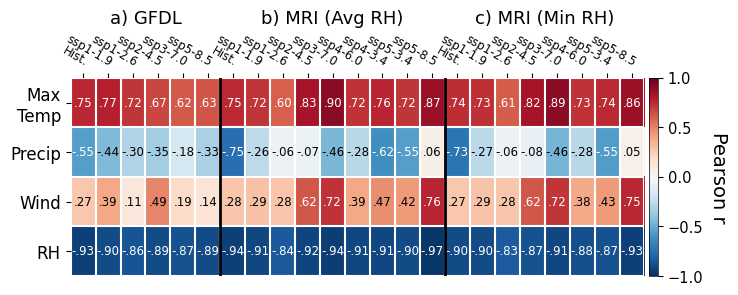

Saved: comparison_merged_heatmap.png


In [80]:
# ── Single merged heatmap: rows=variables, cols=scenarios grouped by model ────
# Journal spec (Weather and Climate Extremes / Elsevier):
#   full double-column width = 190 mm = 7.48 in  |  min font = 8 pt  |  300 DPI

SCENARIO_LABELS = {
    "historical": "Hist.",
    "ssp119": "ssp1-1.9", "ssp126": "ssp1-2.6", "ssp245": "ssp2-4.5",
    "ssp370": "ssp3-7.0", "ssp460": "ssp4-6.0", "ssp434": "ssp4-3.4",
    "ssp534": "ssp5-3.4", "ssp585": "ssp5-8.5",
}

MODEL_CONFIGS = [
    dict(key="GFDL-ESM4",            label="GFDL",
         scenarios=["historical","ssp119","ssp126","ssp245","ssp370","ssp585"]),
    dict(key="MRI-ESM2-0 (hurs)",    label="MRI (Avg RH)",
         scenarios=["historical","ssp119","ssp126","ssp245","ssp370","ssp460","ssp434","ssp534","ssp585"]),
    dict(key="MRI-ESM2-0 (hursmin)", label="MRI (Min RH)",
         scenarios=["historical","ssp119","ssp126","ssp245","ssp370","ssp460","ssp534","ssp585"]),
]

VAR_ORDER  = ["tasmax", "pr", "sfcWind", "hum"]
VAR_LABELS = ["Max\nTemp", "Precip", "Wind", "RH"]

# ── Build full matrix ─────────────────────────────────────────────────────────
all_col_labels = []
group_sizes    = []
full_matrix    = np.full((4, 0), np.nan)

for cfg in MODEL_CONFIGS:
    mdata  = load_model(CACHE[cfg["key"]], HUM_VAR[cfg["key"]], cfg["scenarios"])
    fwi_d  = mdata["fwi"]
    block  = np.full((4, len(cfg["scenarios"])), np.nan)

    for row_i, var in enumerate(VAR_ORDER):
        drv_d = mdata.get(var, {})
        for col_i, s in enumerate(cfg["scenarios"]):
            if s not in fwi_d or s not in drv_d:
                continue
            fwi_v = fwi_d[s].values
            drv_v = UNIT[var](drv_d[s].sel(year=fwi_d[s]["year"], method="nearest")).values
            mask  = np.isfinite(fwi_v) & np.isfinite(drv_v)
            if mask.sum() > 2:
                from scipy.stats import pearsonr
                r, _ = pearsonr(fwi_v[mask], drv_v[mask])
                block[row_i, col_i] = r

    all_col_labels += [SCENARIO_LABELS.get(s, s) for s in cfg["scenarios"]]
    group_sizes.append(len(cfg["scenarios"]))
    full_matrix = np.hstack([full_matrix, block])

# ── Plot ──────────────────────────────────────────────────────────────────────
FIG_W, FIG_H = 7.48, 3.2

n_cols  = full_matrix.shape[1]
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

im = ax.imshow(full_matrix, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="1.5%", pad=0.05)
cbar = fig.colorbar(im, cax=cax, ticks=[-1, -0.5, 0, 0.5, 1])
cbar.ax.set_ylabel("Pearson r", rotation=-90, va="bottom", fontsize=14)
cbar.ax.tick_params(labelsize=10.5)
cbar.outline.set_linewidth(0.5)

ax.set_xticks(range(n_cols))
ax.set_xticklabels(all_col_labels, fontsize=8.5)
ax.set_yticks(range(4))
ax.set_yticklabels(VAR_LABELS, fontsize=12)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
plt.setp(ax.get_xticklabels(), rotation=-30, ha="right", rotation_mode="anchor")

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(n_cols + 1) - .5, minor=True)
ax.set_yticks(np.arange(5) - .5, minor=True)
ax.grid(which="minor", color="w", linestyle="-", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

def _fmt(x, pos):
    return f"{x:.2f}".replace("0.", ".").replace("-0.", "-.")
fmt = matplotlib.ticker.FuncFormatter(_fmt)
for i in range(4):
    for j in range(n_cols):
        val = full_matrix[i, j]
        if np.isfinite(val):
            color = "white" if abs(val) > 0.5 else "black"
            ax.text(j, i, fmt(val, None), ha="center", va="center",
                    color=color, fontsize=8.5)

# Model group dividers (thick white line) + labels
x_pos = -0.5
for grp_i, (cfg, size) in enumerate(zip(MODEL_CONFIGS, group_sizes)):
    mid = x_pos + size / 2
    ax.text(mid, -1.7, f'{chr(97+grp_i)}) {cfg["label"]}', ha="center", va="center",
            fontsize=13, transform=ax.transData)
    x_pos += size
    if x_pos < n_cols - 0.5:
        ax.axvline(x=x_pos, color="black", linewidth=2, zorder=3)

# ax.set_title("Pearson Correlation between FWI and Climate Drivers across SSP Scenarios", pad=28, fontsize=10)

plt.tight_layout()
plt.savefig("Pict/comparison_merged_heatmap.png", dpi=1000, bbox_inches="tight")
plt.show()
print("Saved: comparison_merged_heatmap.png")